## Oscilliscope Test of RFSoC
Short notebook to examine the Pulse sequences at high resolution and frequency

In [35]:
# Adjust if your VS Code kernel needs help finding pip / scripts
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [36]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
from copy import copy
from scipy.optimize import curve_fit
import qickdawg as qd
from importlib.metadata import version

print(f"numpy     {version('numpy')}")
print(f"qickdawg  {version('qickdawg')}")
print(f"python    {sys.version}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
numpy     2.3.2
qickdawg  1.2.1
python    3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


<a id="connect"></a>
### Connect to board

In [38]:
qd.start_client('128.95.31.224')
print("Connected — soccfg loaded:", qd.soccfg is not None)

Connected — soccfg loaded: True


<a id="top"></a>
# Table of Contents
1. [Connect to board](#connect)
2. [Laser](#laser)
3. [PODMR](#podmr)
4. [RABI](#rabi)
5. [CPMG](#cpmg)

<a id="laser"></a>
### Laser

In [39]:
default_config = qd.NVConfiguration()

default_config.adc_channel              = 0
default_config.mw_channel               = 0
default_config.mw_nqz                   = 1
default_config.mw_gain                  = 1800
default_config.laser_gate_pmod          = 0
default_config.laser_on_tus             = 2
default_config.laser_readout_offset_tus = 1.172
default_config.readout_integration_tns  = 300
default_config.mw_laser_delay_treg      = 0
default_config.relax_delay_tus          = 1.1
default_config.pre_init                 = True

# Expected: laser should illuminate the sample
qd.laser_on(copy(default_config))

1.7215686274509805

In [40]:
# Expected: laser should turn off
qd.laser_off(copy(default_config))

2.515686274509804

<a id="podmr"></a>
### PODMR
Edit parameters in `experiments/podmr.py` (EXPERIMENT PARAMETERS block), then run this cell.
The script handles connection, sweep config, acquisition, HDF5 save, and plot internally.
Use `%run -i` to inject variable overrides from a prior cell without editing the file.

[config] Documented Excitation Power is 0.32 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 1843.0 to 1849.0 by 0.2
Instead using 1842.9999996185302 to 1849.000011062622 by 0.20000038146972654 in 31 steps
[podmr] Sweep: 1843.000 -> 1849.000 MHz (delta 0.200 MHz)
[podmr] Active transition: lower_dip | mw_fMHz=1845.9999996185302 MHz | mw_gain=2000
[podmr] pi pulse: OVERRIDE_MW_PI_NS=679.0 ns


  0%|          | 0/3100000 [00:00<?, ?it/s]

[podmr] Saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\podmr\podmr_fine_res_20260320_011616.h5
[podmr] Contrast dip fit: center=1846.167012 MHz, depth=0.390908, width=0.517976 MHz, baseline=0.986551


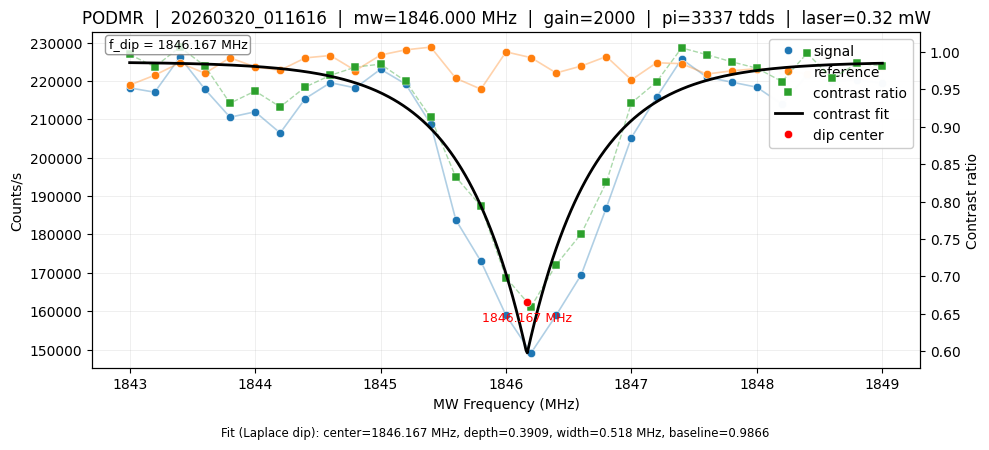

[podmr] Plot saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\podmr\podmr_fine_res_20260320_011616.png


In [55]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/podmr.py

<a id="rabi"></a>
### RABI
Edit parameters in `experiments/rabi.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[config] Documented Excitation Power is 0.32 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[rabi] Sweep: 246 → 1475 tdds  (Δ 25)
[rabi] Active transition: lower_dip | freq=1845.9999996185302 MHz | gain=32767

Requested 246 to 1475 by 25
Instead using 246 to 1471 by 25 in 50


  0%|          | 0/2500000 [00:00<?, ?it/s]

[rabi] Saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_fine_res_20260320_011650.h5
[rabi] Contrast fit (no decay): A=0.174564, T=105.582 ns, C=0.829509


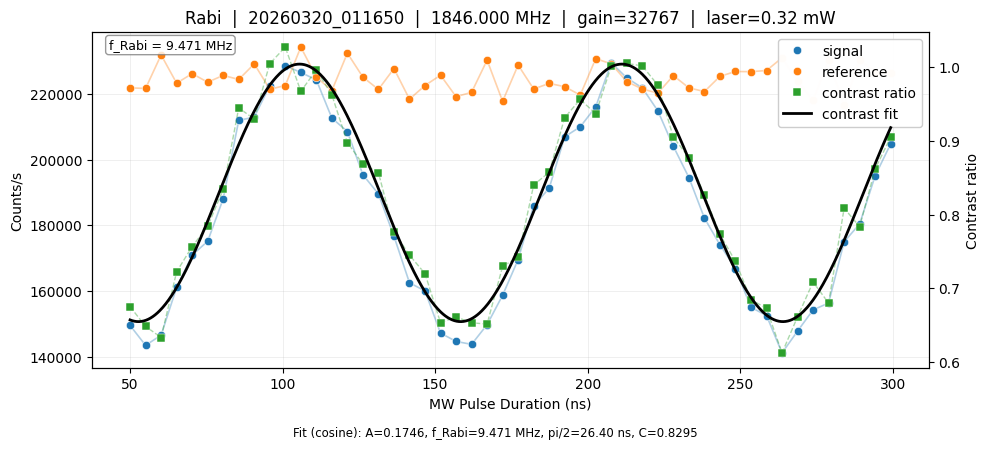

[rabi] Plot saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_fine_res_20260320_011650.png


In [56]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/rabi.py

<a id="cpmg"></a>
### CPMG
Edit parameters in `experiments/cpmg.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

In [52]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/cpmg.py

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 128.95.31.224 ...
[config] Connected.

Requested 200.0 to 201.0 by 0.2
Instead using 199.99186197916669 to 201.00911458333334 by 0.20345052083333334 in 6 steps
[cpmg] Sweep: 199.992 -> 201.009 ftns (delta 0.203)
[cpmg] Active transition: lower_dip | mw_fMHz=1845.8000003814695 MHz | mw_gain=2000
[cpmg] n_cpmg=32, mw_pi2_ftsamp=134, reps=200000


  0%|          | 0/1200000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Read CH1/CH2 traces from a Rohde & Schwarz oscilloscope and plot vs time
import numpy as np
import matplotlib.pyplot as plt
import pyvisa
from pyvisa.util import from_ieee_block

# TODO: set this to your instrument VISA resource string
RESOURCE = "TCPIP0::128.95.31.200::INSTR"

rm = pyvisa.ResourceManager()
scope = rm.open_resource(RESOURCE)
scope.timeout = 20000

# Basic setup / sanity check
idn = scope.query("*IDN?").strip()
print(f"Connected to: {idn}")

# Configure waveform transfer (32-bit float binary)
scope.write("FORM REAL,32")
scope.write("FORM:BORD SWAP")

def read_channel_trace(scope, channel: int):
    # Acquire waveform data for selected channel
    scope.write(f"WAV:SOUR CHAN{channel}")
    preamble = scope.query("WAV:PRE?").strip()
    raw = scope.query_binary_values("WAV:DATA?", datatype='B', container=bytes)
    y = from_ieee_block(raw, datatype="f", is_big_endian=False)

    # Parse preamble for horizontal scaling (model-dependent, common R&S format)
    # Expected first values: format,type,points,count,x_increment,x_origin,x_ref,y_increment,y_origin,y_ref
    p = [v.strip() for v in preamble.split(",")]
    x_inc = float(p[4])
    x_org = float(p[5])
    x_ref = float(p[6])
    n = len(y)
    t = (np.arange(n) - x_ref) * x_inc + x_org
    return t, np.asarray(y, dtype=float)

t1, ch1 = read_channel_trace(scope, 1)
t2, ch2 = read_channel_trace(scope, 2)

scope.close()
rm.close()

# Use CH1 time base unless lengths differ
if len(t1) == len(t2) and np.allclose(t1, t2):
    t = t1
else:
    # Fall back: interpolate CH2 onto CH1 time axis if needed
    t = t1
    ch2 = np.interp(t1, t2, ch2)

plt.figure(figsize=(10, 5))
plt.plot(t, ch1, label="CH1", lw=1.2)
plt.plot(t, ch2, label="CH2", lw=1.2)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Oscilloscope Traces: CH1 and CH2")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Connected to: Rohde&Schwarz,MXO58,1802.1008k08/101590,2.7.2.2


VisaIOError: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.